In [56]:
# Set up environment
%load_ext autoreload
%autoreload 2
%matplotlib notebook
%matplotlib inline

import torch
import numpy as np

import matplotlib.pyplot as plt
import imageio
from PIL import Image

import trimesh
import pyrender

In [66]:
from os import path as osp
import glob
support_dir = 'human_body_prior\support_data\dowloads\V02_05\snapshots\V02_05_epoch=13_val_loss=0.03.ckpt'  
glob.glob(osp.join('\\', '\\'.join(support_dir.split('\\')[:-2]), '*.yaml'))     #'/support_data/dowloads'
# expr_dir = osp.join(support_dir,'V02_05')                                         #'TRAINED_MODEL_DIRECTORY'  in this directory the trained model along with the model code exist
# bm_fname =  osp.join(support_dir,'models/smplx/neutral/SMPLX_NEUTRAL.npz')        #'PATH_TO_SMPLX_model.npz'  obtain from https://smpl-x.is.tue.mpg.de/downloads
# sample_amass_fname = osp.join(support_dir, 'amass_sample.npz')                    # a sample npz file from AMASS

# print(expr_dir)
# print(bm_fname)
# print(sample_amass_fname)
# from pathlib import Path

# support_dir = Path(r"C:\Abishek\SMPLify\human_body_prior\support_data\dowloads").resolve()
# expr_dir = support_dir / 'V02_05'
# bm_fname = (support_dir / 'models' / 'smplx' / 'neutral' / 'SMPLX_NEUTRAL.npz').resolve().as_posix()
# sample_amass_fname = (support_dir / 'amass_sample.npz').resolve().as_posix()

# print(expr_dir.as_posix())
# print(bm_fname)
# print(sample_amass_fname)
glob.glob(osp.join('\\', '\\'.join(support_dir.split('\\')[:-2]), '*.yaml'))

[]

In [3]:
#Loading SMPLx Body Model
from human_body_prior.body_model.body_model import BodyModel

bm = BodyModel(bm_fname=bm_fname).to('cuda')

In [4]:
#Loading VPoser Body Pose Prior
from human_body_prior.tools.model_loader import load_model
from human_body_prior.models.vposer_model import VPoser
vp, ps = load_model(expr_dir, model_code=VPoser,
                              remove_words_in_model_weights='vp_model.',
                              disable_grad=True)
vp = vp.to('cuda')


#vp is the VPoser architecture with loaded weights
# ps is the configuration file of the Vposer architecture


2026-07-05 11:18:14.207 | INFO     | human_body_prior.tools.model_loader:load_model:104 - Loaded model in eval mode with trained weights: C:\Abishek\SMPLify\human_body_prior\support_data\dowloads\V02_05\snapshots\V02_05_epoch=08_val_loss=0.03.ckpt


C:\Abishek\SMPLify\human_body_prior\support_data\dowloads\V02_05\snapshots\V02_05_epoch=08_val_loss=0.03.ckpt


In [5]:
# Prepare the pose_body from amass sample
amass_body_pose = np.load(sample_amass_fname)['poses'][:, 3:66]
print(amass_body_pose.shape)
amass_body_pose = torch.from_numpy(amass_body_pose).type(torch.float).to('cuda')
print('amass_body_pose.shape', amass_body_pose.shape)

(500, 63)
amass_body_pose.shape torch.Size([500, 63])


In [6]:
amass_body_poZ = vp.encode(amass_body_pose).mean
print('amass_body_poZ.shape', amass_body_poZ.shape)

amass_body_poZ.shape torch.Size([500, 32])


In [7]:
amass_body_poZ[0].std()

tensor(0.8267, device='cuda:0')

In [8]:
amass_body_pose_rec = vp.decode(amass_body_poZ)['pose_body'].contiguous().view(-1, 63)
print('amass_body_pose_rec.shape', amass_body_pose_rec.shape)

amass_body_pose_rec.shape torch.Size([500, 63])


In [9]:
##Let's visualize the original pose and the reconstructed one:

t = np.random.choice(len(amass_body_pose))
print(t)

all_pose_body = torch.stack([amass_body_pose[t], amass_body_pose_rec[t]])

all_pose_body.shape

23


torch.Size([2, 63])

In [10]:
body = bm(
    pose_body=all_pose_body,
    num_betas= 10
)

425


(np.float64(-0.5), np.float64(511.5), np.float64(511.5), np.float64(-0.5))

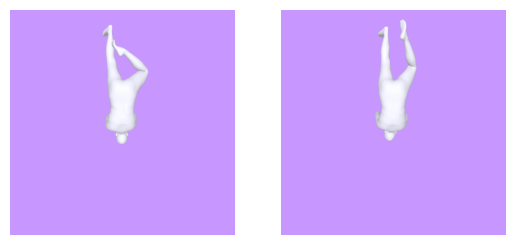

In [31]:
t = np.random.choice(len(amass_body_pose))
print(t)

all_pose_body = torch.stack([amass_body_pose[t], amass_body_pose_rec[t]])

all_pose_body.shape
body = bm(
    pose_body=all_pose_body,
    num_betas= 10
)
img1 = render_smpl(
    body.v[0].detach().cpu().numpy(),
    body.f.detach().cpu().numpy()
)
img2 = render_smpl(
    body.v[1].detach().cpu().numpy(),
    body.f.detach().cpu().numpy()
)
plt.subplot(1,2,1)
plt.imshow(img1)
plt.axis('off')
plt.subplot(1,2,2)
plt.imshow(img2)
plt.axis("off")

In [30]:
import numpy as np
import trimesh
import pyrender


def render_smpl(vertices,
                faces,
                resolution=(512, 512)):

    mesh = trimesh.Trimesh(
        vertices,
        faces,
        process=False
    )

    # Convert SMPL coordinate system to OpenGL
    rot = trimesh.transformations.rotation_matrix(
        np.radians(180),
        [1, 0, 0]
    )
    mesh.apply_transform(rot)

    material = pyrender.MetallicRoughnessMaterial(
        metallicFactor=0.0,
        roughnessFactor=0.8,
        baseColorFactor=(0.75, 0.75, 0.85, 1.0)
    )

    mesh = pyrender.Mesh.from_trimesh(
        mesh,
        material=material,
        smooth=True
    )

    scene = pyrender.Scene(
        bg_color=[200, 150, 255, 0],
        ambient_light=(0.4, 0.4, 0.4)
    )

    scene.add(mesh)

    camera = pyrender.PerspectiveCamera(
        yfov=np.pi/3
    )

    camera_pose = np.eye(4)
    camera_pose[:3, 3] = [0, 0, 2.5]

    scene.add(camera, pose=camera_pose)

    light = pyrender.DirectionalLight(
        color=np.ones(3),
        intensity=3.0
    )

    scene.add(light, pose=camera_pose)

    renderer = pyrender.OffscreenRenderer(
        resolution[0],
        resolution[1]
    )

    color, _ = renderer.render(scene)

    renderer.delete()

    return color

In [2]:
import torch
torch.cuda.is_available()

True

In [1]:
import onnxruntime as ort
print(ort.get_available_providers())


['TensorrtExecutionProvider', 'CUDAExecutionProvider', 'CPUExecutionProvider']


load C:\Users\hp\.cache\rtmlib\hub\checkpoints\yolox_m_8xb8-300e_humanart-c2c7a14a.onnx with onnxruntime backend
load C:\Users\hp\.cache\rtmlib\hub\checkpoints\rtmw-dw-x-l_simcc-cocktail14_270e-256x192_20231122.onnx with onnxruntime backend
8
(1, 134, 2)


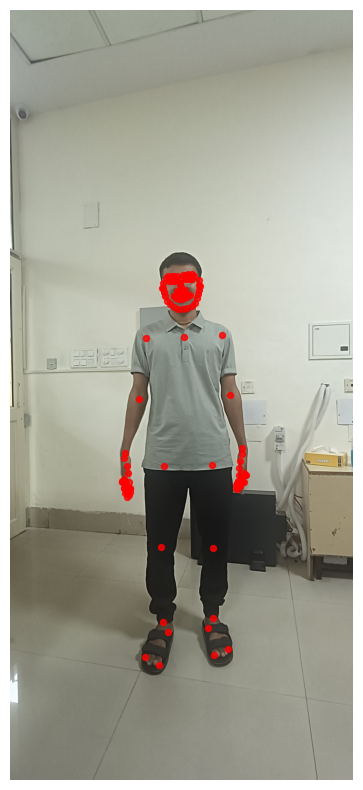

In [32]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os
from rtmlib import Wholebody


img_folder= r"C:\Abishek\SMPLify\DATA_FOLDER\images"
# img = cv2.imread(img_path)
img_path = [os.path.join(img_folder,item) for item in os.listdir(img_folder)]
wholebody = Wholebody(to_openpose=True, mode='balanced', backend='onnxruntime', device='cuda')
kpts = []
for img in img_path:
    img = cv2.imread(img)
    kpts.append(wholebody(img))
print(len(kpts))
print(kpts[0][0].shape)




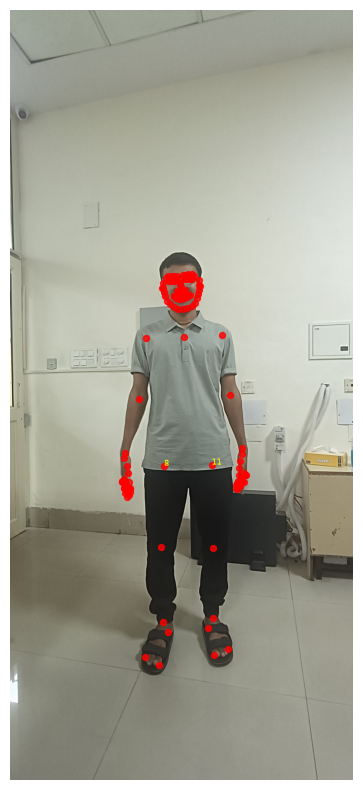

In [53]:
# kpts expected shape: (num_people, num_joints, 3) --> plot all keypoints
id = 0  # 0<= id <= 7
img = cv2.imread(img_path[id])
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
plt.figure(figsize=(10,10))
plt.imshow(img_rgb)
for person_id in range(kpts[id][0].shape[0]):
    pts = kpts[id][0][person_id][:,:2]  # x,y
    plt.scatter(pts[:,0], pts[:,1], s=18, c='red', alpha=0.8)
    # annotate indices so you can see the keypoint order (optional)
    for i, (x,y) in enumerate(pts):
        if i == 8 or i == 11:
            plt.text(x, y, str(i), color='yellow', fontsize=6)
        # if i != 0 and i % 10 == 0:
        #     break

plt.axis('off')
plt.show()

In [47]:
print(os.path.join(os.path.dirname(r"C:\Users\hp\anaconda3\envs\smplify\Lib\site-packages\rtmlib\__init__.py"), 'tools', 'solution', 'wholebody.py'))

C:\Users\hp\anaconda3\envs\smplify\Lib\site-packages\rtmlib\tools\solution\wholebody.py


In [55]:
import sys
import os
os.path.abspath(os.path.join(os.path.dirname(__file__), os.pardir))

NameError: name '__file__' is not defined